## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [28]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_csv('../data/activities.csv')


## 2. Inspect df and select rows with date_1 values

In [29]:
print('The number of df columns with only NaN values in original df:')
print(len(df.columns[df.isnull().all()]))

# Remove columns with only NaN values
df =df.dropna(axis=1, how='all')

print("--------------------------------")
print('The number of df columns with only NaN values in cleaned df is:')
print(len(df.columns[df.isnull().all()]))

print("--------------------------------")
print('df columns are:')
print(list(df.columns))
print("")
print(f'original df shape is {df.shape}')

print("--------------------------------")
df["Afstand"] = pd.to_numeric(df["Afstand"], errors='coerce')
print(f'Afstand dtypes is:{df["Afstand"].dtypes}')

print(df[["Verstreken tijd", "Verstreken tijd.1", "Beweegtijd", "Gemiddelde snelheid", "Gemiddelde hartslag","Gemiddelde snelheid (op basis van verstreken tijd)", "Gemiddelde vergelijkbare tempo op vlak terrein"]].describe())



The number of df columns with only NaN values in original df:
30
--------------------------------
The number of df columns with only NaN values in cleaned df is:
0
--------------------------------
df columns are:
['Activiteits-ID', 'Datum van activiteit', 'Naam activiteit', 'Activiteitstype', 'Beschrijving van activiteit', 'Verstreken tijd', 'Afstand', 'Max. hartslag', 'Vergelijkbare poging', 'Woon-werkverkeer', 'Uitrusting voor activiteit', 'Bestandsnaam', 'Gewicht fiets', 'Verstreken tijd.1', 'Beweegtijd', 'Afstand.1', 'Max. snelheid', 'Gemiddelde snelheid', 'Totale stijging', 'Totale daling', 'Kleinste hoogte', 'Grootste hoogte', 'Max. stijgingspercentage', 'Gemiddeld stijgingspercentage', 'Max. cadans', 'Gemiddelde cadans', 'Max. hartslag.1', 'Gemiddelde hartslag', 'Gemiddeld wattage', 'Calorieën', 'Gemiddelde temperatuur', 'Vergelijkbare poging.1', 'Voorkeur voor ervaren inspanning', 'Woon-werkverkeer.1', 'Van upload', 'Aan stijgingspercentage aangepaste afstand', 'Tijd weerbeeld'

## 3. Clean Date feature

In [ ]:
months = {
    # volledige namen
    'januari': 'January',
    'februari': 'February',
    'maart': 'March',
    'april': 'April',
    'mei': 'May',
    'juni': 'June',
    'juli': 'July',
    'augustus': 'August',
    'september': 'September',
    'oktober': 'October',
    'november': 'November',
    'december': 'December',

    # afkortingen
    'jan': 'January',
    'feb': 'February',
    'mrt': 'March',
    'apr': 'April',
    'mei': 'May',
    'jun': 'June',
    'jul': 'July',
    'aug': 'August',
    'sep': 'September',
    'okt': 'October',
    'nov': 'November',
    'dec': 'December',
}

df['Datum van activiteit_en'] = df['Datum van activiteit'].str.lower()
for nl, en in months.items():
    df['Datum van activiteit_en'] = df['Datum van activiteit_en'].str.replace(nl, en, regex=False)

df['Datum van activiteit'] = pd.to_datetime(
    df['Datum van activiteit_en'],
    format='%d %B %Y, %H:%M:%S'
)

df.drop(columns='Datum van activiteit_en', inplace=True)
df['Datum van activiteit'] = pd.to_datetime(df['Datum van activiteit'])
df['Date']= df['Datum van activiteit'].dt.date
df['Year'] = df['Datum van activiteit'].dt.year
df['Month'] =df['Datum van activiteit'].dt.month
df['Quarter']= df['Datum van activiteit'].dt.quarter
df['Week']=df['Datum van activiteit'].dt.isocalendar().week


print("--------------------------------")

print(f'Data were collected starting from:{df["Date"].min()}')


--------------------------------
Data were collected starting from:2017-04-15


## 3. Explore features

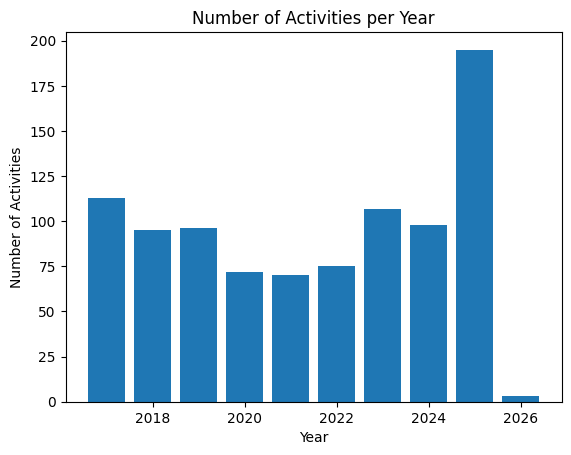

Unique values in "Type activiteit" column:
['Hardloopsessie' 'Fietsrit' 'Wandeling' 'Kayakken' 'Kitesurfen'
 'Training' 'Zwemmen']
The number of activities of type "Hardloopsessie" is: 541
The number of activities of type "Fietsrit" is: 305
The number of activities of type "Wandeling" is: 6
The number of activities of type "Kayakken" is: 1
The number of activities of type "Kitesurfen" is: 1
The number of activities of type "Training" is: 7
The number of activities of type "Zwemmen" is: 63
   Year  Afstand.1
0  2017   574.7298
1  2018   615.7599
2  2019   622.5719
3  2020   368.8266
4  2021   341.0631
5  2022   302.3613
6  2023   703.4343
7  2024   382.6790
8  2025   489.5776
9  2026    16.0146


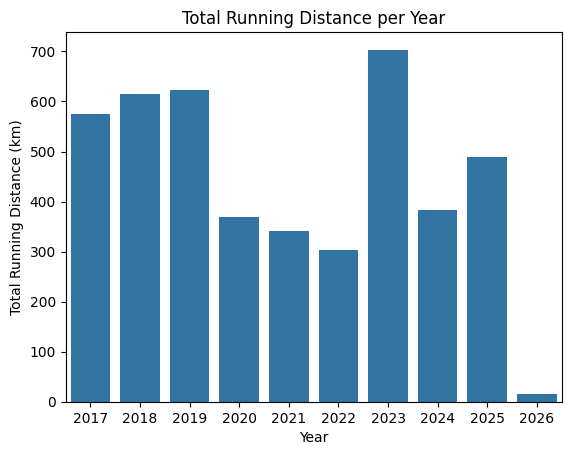

   Year  Afstand.1
0  2017  1493.6029
1  2018   640.1962
2  2019  1637.5130
3  2020   806.2230
4  2021  1711.0576
5  2022  2790.2550
6  2023  1269.0020
7  2024  2546.8806
8  2025  3023.2023


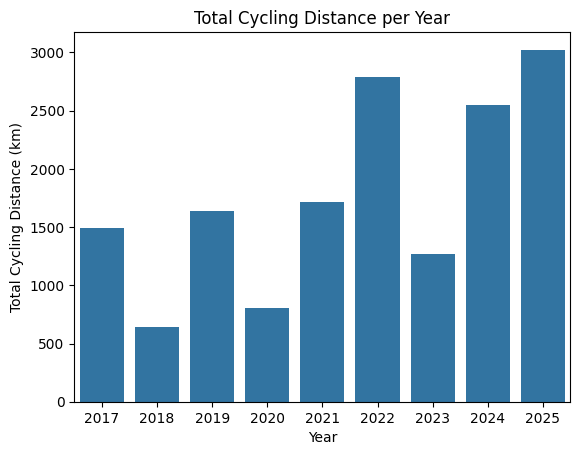

In [31]:
# Count the number of activities per year
df_by_year = df['Year'].value_counts().sort_index()

plt.bar(df_by_year.index, df_by_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Activities')
plt.title('Number of Activities per Year')
plt.show()


# print uniques values in 'Type activiteit' column
print('Unique values in "Type activiteit" column:')
print(df['Activiteitstype'].unique())
all_activity_types = df['Activiteitstype'].unique().tolist()

for i in range(len(all_activity_types)):
    print(f'The number of activities of type "{all_activity_types[i]}" is: {len(df[df["Activiteitstype"] == all_activity_types[i]])}')


df_run = df[df['Activiteitstype'] == 'Hardloopsessie']
df_run_by_year = pd.DataFrame(df_run.groupby('Year')['Afstand.1'].sum())/1000
df_run_by_year = df_run_by_year.reset_index()  # 'Year' wordt een gewone kolom
print(df_run_by_year)

sns.barplot(data=df_run_by_year, x='Year', y='Afstand.1')
plt.xlabel('Year')
plt.ylabel('Total Running Distance (km)')
plt.title('Total Running Distance per Year')
plt.show()

df_bike = df[df['Activiteitstype'] == 'Fietsrit']
df_bike_by_year = pd.DataFrame(df_bike.groupby('Year')['Afstand.1'].sum())/1000
df_bike_by_year = df_bike_by_year.reset_index()  # 'Year' wordt een gewone kolom
print(df_bike_by_year)

sns.barplot(data=df_bike_by_year, x='Year', y='Afstand.1')
plt.xlabel('Year')
plt.ylabel('Total Cycling Distance (km)')
plt.title('Total Cycling Distance per Year')
plt.show()

## 4. Activity distances and time per month

C:\Users\jasmi\AppData\Local\Temp\ipykernel_2472\1747880853.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '63.858866666666664' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_run_by_year_month.loc[df_run_by_year_month['Year'] == year, 'monthly_average'] = monthly_avg


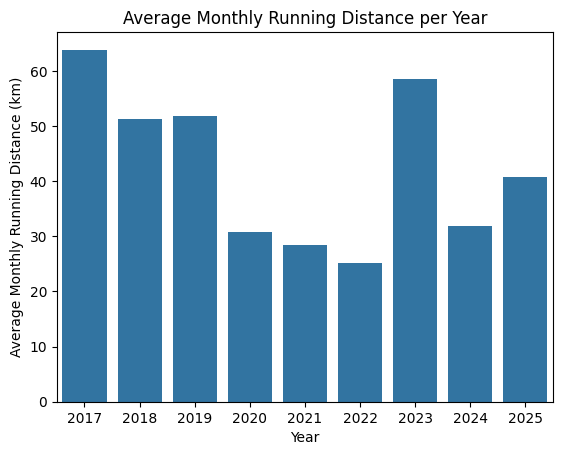

In [32]:
# Calculate monthly running distance per year
df_run = df[df['Activiteitstype'] == 'Hardloopsessie']
df_run_by_year_month = pd.DataFrame(df_run.groupby(['Year', 'Month'])['Afstand.1'].sum())/1000
df_run_by_year_month = df_run_by_year_month.reset_index()  # 'Year' and 'Month' become regular columns
df_run_by_year_month = df_run_by_year_month[df_run_by_year_month['Year'] != 2026]



# Create an empty column first
df_run_by_year_month['monthly_average'] = 0

for year in df_run_by_year_month['Year'].unique():
    # Filter rows for this year
    yearly_data = df_run_by_year_month[df_run_by_year_month['Year'] == year]
    
    # Decide divisor
    if year == 2017:
        divisor = 9
    else:
        divisor = 12

    # Calculate monthly average for this year
    monthly_avg = yearly_data['Afstand.1'].sum() / divisor
    
    # Assign it back to df_run_by_year_month for rows of this year
    df_run_by_year_month.loc[df_run_by_year_month['Year'] == year, 'monthly_average'] = monthly_avg

sns.barplot(data=df_run_by_year_month, x='Year', y='monthly_average')
plt.xlabel('Year')
plt.ylabel('Average Monthly Running Distance (km)')
plt.title('Average Monthly Running Distance per Year')
plt.show()

## 6. Calculate average running pace (min/km) or cycling speed (km/h) 

In [33]:
# Average running speed (min/km)
df_run['Running pace numeric'] = (1000*df_run['Beweegtijd'])/ (60*df_run['Afstand.1']).replace(0, np.nan)

# Convert to min:sec/km safely
def min_to_mmss(x):
    if pd.isna(x) or not math.isfinite(x):
        return np.nan

    minutes = int(x)
    seconds = int(round((x - minutes) * 60))

    # handle rounding edge case (e.g. 4.999 → 5:00)
    if seconds == 60:
        minutes += 1
        seconds = 0

    return f"{minutes}:{seconds:02d}"


df_run['Running pace string'] = (
    df_run['Running pace numeric']
    .apply(min_to_mmss)
)

print(df_run['Running pace string'].describe())


count      507
unique      96
top       4:56
freq        24
Name: Running pace string, dtype: object


C:\Users\jasmi\AppData\Local\Temp\ipykernel_2472\4081127212.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_run['Running pace numeric'] = (1000*df_run['Beweegtijd'])/ (60*df_run['Afstand.1']).replace(0, np.nan)
C:\Users\jasmi\AppData\Local\Temp\ipykernel_2472\4081127212.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_run['Running pace string'] = (


## 6. Plot Running pace

C:\Users\jasmi\AppData\Local\Temp\ipykernel_2472\1532601081.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([min_to_mmss(y) for y in yticks])


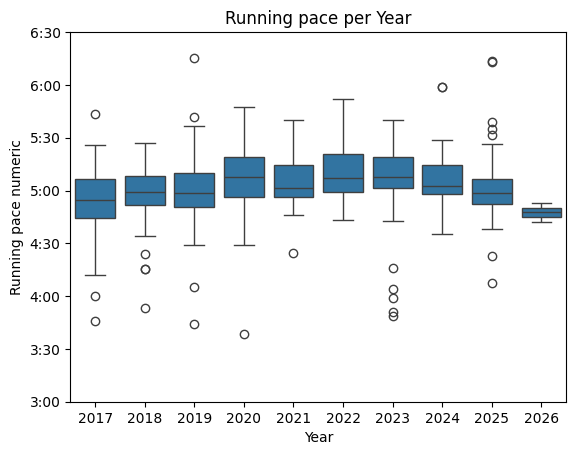

In [40]:
sns.boxplot(data=df_run, y='Running pace numeric', x= 'Year')
plt.xlabel('Year')
plt.ylim(3,6.5)
plt.title('Running pace per Year')
# Get current Y-ticks
yticks = plt.gca().get_yticks()

# Convert them to mm:ss
plt.gca().set_yticklabels([min_to_mmss(y) for y in yticks])

plt.show()

## 7. Plot Cycling speed

C:\Users\jasmi\AppData\Local\Temp\ipykernel_2472\3327565635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bike['bike_speed'] = 3600*(df_bike['Afstand.1']/1000) / (df_bike['Beweegtijd']).replace(0, np.nan)


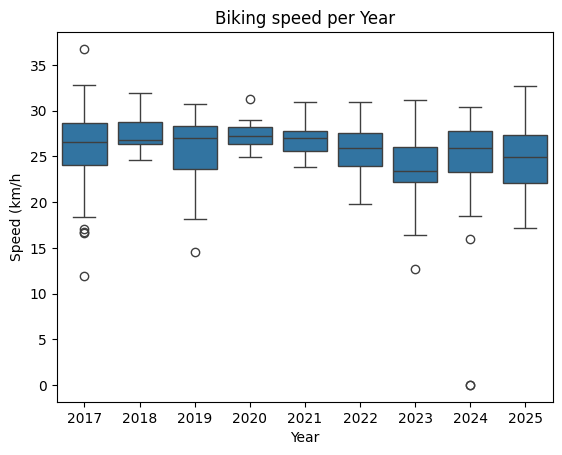

In [47]:
df_bike = df[df['Activiteitstype']=='Fietsrit']
df_bike['bike_speed'] = 3600*(df_bike['Afstand.1']/1000) / (df_bike['Beweegtijd']).replace(0, np.nan)


sns.boxplot(data=df_bike, y='bike_speed', x='Year')
plt.xlabel('Year')
plt.title('Biking speed per Year')
plt.ylabel('Speed (km/h')
plt.show()


## 8. Calculate weekly time spent per sport in 2025

In [ ]:
df_2025= df[df['Year'] == 2025]
df_2025_run = df_2025[df_2025['Activiteitstype'] == 'Hardloopsessie']
df_2025_bike = df_2025[df_2025['Activiteitstype'] == 'Fietsrit']
df_2025_swim = df_2025[df_2025['Activiteitstype'] == 'Zwemmen']

